gt : [ 0.         1.4389334  1.4413639 ... 20.005781  20.029388  20.09091  ]
depth : [ 1.1018533  1.1020241  1.1021925 ... 29.90535   29.908363  29.921154 ]
0.0 22.46788
gt_check_value : 0.0
abs_rel_depth : inf
abs_rel_crm : inf
rmse_depth : 17.686983108520508
rmse_crm : 14.959192276000977


/tmp/ipykernel_3519051/2852640724.py:36: RuntimeWarning: divide by zero encountered in divide
  abs_rel_depth = np.mean(np.abs(depth[valid_mask > 0] - gt_check[valid_mask > 0]) / gt_check[valid_mask > 0])
/tmp/ipykernel_3519051/2852640724.py:38: RuntimeWarning: divide by zero encountered in divide
  abs_rel_crm = np.mean(np.abs(depth_crm[valid_mask > 0] - gt_check[valid_mask > 0]) / gt_check[valid_mask > 0])


(-0.5, 639.5, 359.5, -0.5)

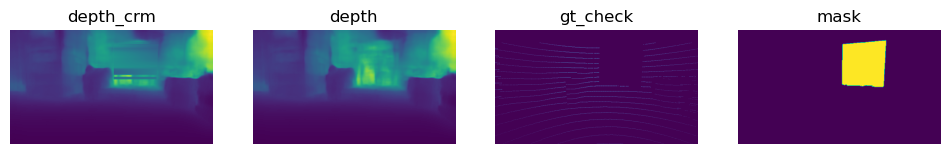

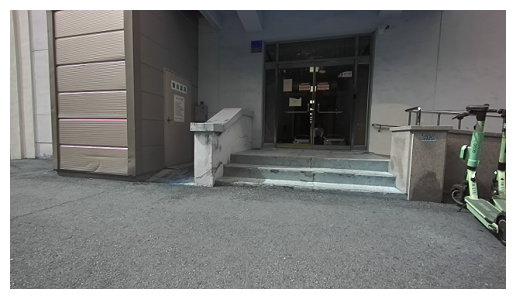

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

drive = 7
index = 700
# 이미지 불러오기
# depth = np.load("/ssd1/jm_data/depth/ssl/monodepth2/jbnu_stereo/2025_03_23/2025_03_23_drive_0003_sync/proj_depth/groundtruth/image_03/0000001329.npy")
rgb = cv2.imread(f"/ssd1/jm_data/depth/ssl/monodepth2/jbnu_stereo/2025_05_08/2025_05_08_drive_{str(drive).zfill(4)}_sync/image_02/data/{str(index).zfill(10)}.png")
gt = np.load(f"/ssd1/jm_data/depth/ssl/monodepth2/jbnu_stereo/2025_05_08/2025_05_08_drive_{str(drive).zfill(4)}_sync/proj_depth/groundtruth/image_02/{str(index).zfill(10)}.npy")
depth = np.load(f"/ssd1/jm_data/depth/ssl/monodepth2/jbnu_stereo/2025_05_08/2025_05_08_drive_{str(drive).zfill(4)}_sync/proj_depth/groundtruth_origin/image_02/{str(index).zfill(10)}.npy")
depth_crm = np.load(f"/ssd1/jm_data/depth/ssl/monodepth2/jbnu_stereo/2025_05_08/2025_05_08_drive_{str(drive).zfill(4)}_sync/proj_depth/groundtruth_crm/image_02/{str(index).zfill(10)}.npy")
mask = cv2.imread(f"/ssd1/jm_data/Grounded-Segment-Anything/outputs/2025_05_08/2025_05_08_drive_{str(drive).zfill(4)}_sync/image_02/mask/{str(index).zfill(10)}.png")

# 정규화: [0, 255] → [0, 1]
mask = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)
mask = cv2.resize(mask, (gt.shape[1], gt.shape[0]))
mask = (mask > 50).astype(np.uint8)

gt_value = gt[133, 352]
depth_value = depth[133, 352]
print(f"gt : {np.unique(gt)}")
print(f"depth : {np.unique(depth)}")
print(gt_value, depth_value)
gt_check = gt.copy()
depth_check = depth.copy()
valid_mask = mask > 0
valid_mask = valid_mask.astype(np.uint8)
valid_mask = valid_mask * gt

gt_check[valid_mask > 0] = gt_value
gt_check_value = gt_check[133, 352]
print(f"gt_check_value : {gt_check_value}")

abs_rel_depth = np.mean(np.abs(depth[valid_mask > 0] - gt_check[valid_mask > 0]) / gt_check[valid_mask > 0])
print(f"abs_rel_depth : {abs_rel_depth}")
abs_rel_crm = np.mean(np.abs(depth_crm[valid_mask > 0] - gt_check[valid_mask > 0]) / gt_check[valid_mask > 0])
print(f"abs_rel_crm : {abs_rel_crm}")

rmse_depth = np.sqrt(np.mean((depth[valid_mask > 0] - gt_check[valid_mask > 0]) ** 2))
print(f"rmse_depth : {rmse_depth}")
rmse_crm = np.sqrt(np.mean((depth_crm[valid_mask > 0] - gt_check[valid_mask > 0]) ** 2))
print(f"rmse_crm : {rmse_crm}")
# 시각화
plt.figure(figsize=(12,6))
plt.subplot(1,4,1)
plt.imshow(depth_crm)
plt.title("depth_crm")
plt.axis('off')
plt.subplot(1,4,2)
plt.imshow(depth)
plt.title("depth")
plt.axis('off')
plt.subplot(1,4,3)
plt.imshow(gt_check)
plt.title("gt_check")
plt.axis('off')
plt.subplot(1,4,4)
plt.imshow(mask)
plt.title("mask")
plt.axis('off')

plt.figure()
plt.imshow(rgb, cmap="magma_r")
plt.axis("off")